<a href="https://colab.research.google.com/github/Felipe-Ulloa-CA/bus-eta-prediction/blob/main/bus_eta_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Executive Summary

This study evaluates whether machine learning models using structural GTFS features can improve bus trip duration prediction compared to schedule-based estimation.

A Random Forest baseline model achieved a 16% reduction in RMSE compared to Linear Regression and explained approximately 30.8% of trip duration variance.


# Introduction

## Problem Statement

Santiago’s public transportation system frequently relies on schedule-based ETA predictions, which often fail to reflect real operational variability.

This project investigates whether supervised machine learning models leveraging GTFS-based structural and operational features can improve prediction accuracy of bus trip durations relative to simple schedule-based approaches.

## Research Question

Can machine learning models using GTFS-derived structural features reduce ETA prediction error compared to traditional schedule-based estimation?



# Data Sources

The primary data source is the official GTFS dataset published by the Dirección de Transporte Público Metropolitano (DTPM), Chile.

Key files used in this analysis include:

- stop_times.txt (trip stop sequences and timestamps)
- trips.txt (trip-level metadata)
- routes.txt
- calendar.txt
- transfers.txt

These files allow reconstruction of trip durations and structural route characteristics.


In [104]:
# Core libraries
import os
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [105]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [106]:
os.listdir("/content/drive/MyDrive/bus_eta_project/data")


['trips.txt',
 'pathways.txt',
 'frequencies.txt',
 'stop_times.txt',
 'agency.txt',
 'calendar_dates.txt',
 'transfers.txt',
 'shapes.txt',
 'stops.txt',
 'calendar.txt',
 'routes.txt',
 'feed_info.txt']

In [107]:


stop_times = pd.read_csv(
    "/content/drive/MyDrive/bus_eta_project/data/stop_times.txt",
    usecols=["trip_id", "arrival_time", "departure_time", "stop_id", "stop_sequence"],
    dtype={
        "trip_id": "string",
        "stop_id": "string",
        "stop_sequence": "int32"
    }
)

trips = pd.read_csv(
    "/content/drive/MyDrive/bus_eta_project/data/trips.txt",
    dtype={"trip_id": "string"}
)



In [108]:
stop_times.shape


(845952, 5)

In [109]:
def time_to_seconds(t):
    try:
        h, m, s = map(int, t.split(":"))
        return h*3600 + m*60 + s
    except:
        return None

stop_times["arrival_seconds"] = stop_times["arrival_time"].apply(time_to_seconds)


In [110]:
trip_duration = (
    stop_times
    .groupby("trip_id")
    .agg(
        start_time=("arrival_seconds", "min"),
        end_time=("arrival_seconds", "max")
    )
)

trip_duration["trip_duration_seconds"] = (
    trip_duration["end_time"] - trip_duration["start_time"]
)

trip_duration = trip_duration[
    trip_duration["trip_duration_seconds"] > 0
]

model_data = trip_duration.merge(trips, on="trip_id")

# Remove duplicate rows
model_data = model_data.drop_duplicates()

# Check missing values
print("Missing values per column:")
print(model_data.isnull().sum())



Missing values per column:
trip_id                      0
start_time                   0
end_time                     0
trip_duration_seconds        0
route_id                     0
service_id                   0
trip_headsign                0
direction_id                 0
shape_id                     0
wheelchair_accessible    14462
bikes_allowed            14586
dtype: int64


### Data Cleaning

Duplicate records were removed to prevent modeling bias.

Missing values were inspected. While some columns such as `wheelchair_accessible` and `bikes_allowed` contain missing values, these variables were not used in the baseline modeling features.

The selected modeling features contain no missing values, so no imputation was required at this stage.



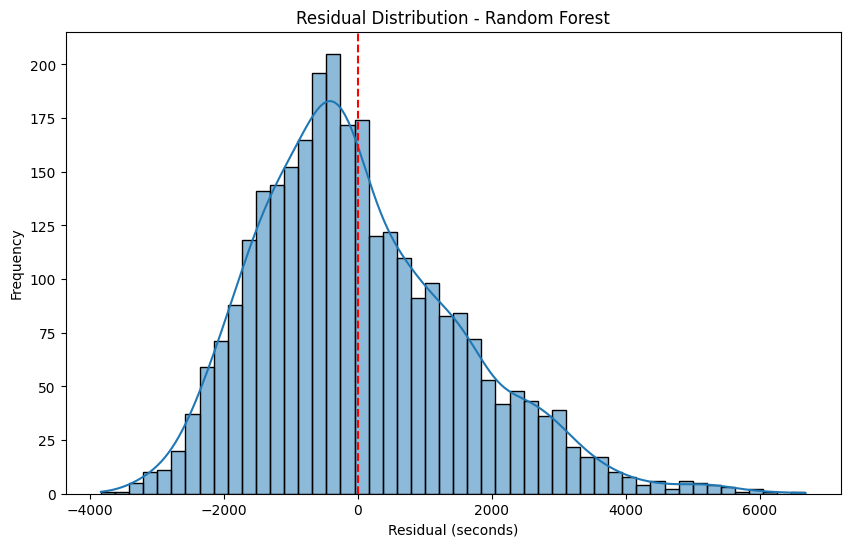

In [111]:


plt.figure(figsize=(10,6))
sns.histplot(residuals, bins=50, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title("Residual Distribution - Random Forest")
plt.xlabel("Residual (seconds)")
plt.ylabel("Frequency")
plt.show()



In [112]:
model_data = model_data[
    model_data["trip_duration_seconds"] < 3 * 3600
]

model_data["trip_duration_minutes"] = model_data["trip_duration_seconds"] / 60

model_data["is_weekend"] = model_data["service_id"].isin(["S", "D"]).astype(int)

route_trip_count = model_data.groupby("route_id").size()
model_data["route_trip_count"] = model_data["route_id"].map(route_trip_count)


In [113]:
features = [
    "direction_id",
    "is_weekend",
    "route_trip_count"
]

X = model_data[features]
y = model_data["trip_duration_seconds"]


## Baseline Modeling Strategy

The objective of this section is to establish a structural performance baseline using static GTFS-derived features.

This baseline quantifies the explanatory power of schedule-based structural information prior to incorporating dynamic operational signals.

The model will be evaluated using MAE, RMSE, and R² to assess both absolute error magnitude and explained variance.


In [114]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [115]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)



In [116]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)


Linear Regression MAE: 1480.7528957972506
Linear Regression RMSE: 1831.7085198661966


In [117]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)



Random Forest MAE: 1209.4418714923142
Random Forest RMSE: 1540.7466132564666
Random Forest R²: 0.30812998593740903


In [118]:
print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)


Linear Regression MAE: 1480.7528957972506
Linear Regression RMSE: 1831.7085198661966
Random Forest MAE: 1209.4418714923142
Random Forest RMSE: 1540.7466132564666
Random Forest R²: 0.30812998593740903


In [119]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE (sec)": [mae_lr, mae_rf],
    "RMSE (sec)": [rmse_lr, rmse_rf],
    "R²": [None, r2_rf]
})

results = results.round(2)

results



,Model,MAE (sec),RMSE (sec),R²
0,Linear Regression,1480.75,1831.71,NaN
1,Random Forest,1209.44,1540.75,0.31


### Model Comparison

Random Forest significantly outperforms Linear Regression across MAE and RMSE metrics.

The Random Forest model reduces RMSE by approximately 15.9% and explains 30.8% of the variance in trip duration, demonstrating the value of nonlinear modeling for structural GTFS features.


In [120]:
# Extract feature importance
importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

feature_importance_df



,Feature,Importance
2,route_trip_count,0.928198
1,is_weekend,0.048846
0,direction_id,0.022955


### Feature Importance Analysis

Route-level intensity (route_trip_count) and directional structure appear to contribute most to trip duration variability.

This indicates that structural operational characteristics partially explain travel time differences, though substantial unexplained variance remains due to missing dynamic features.


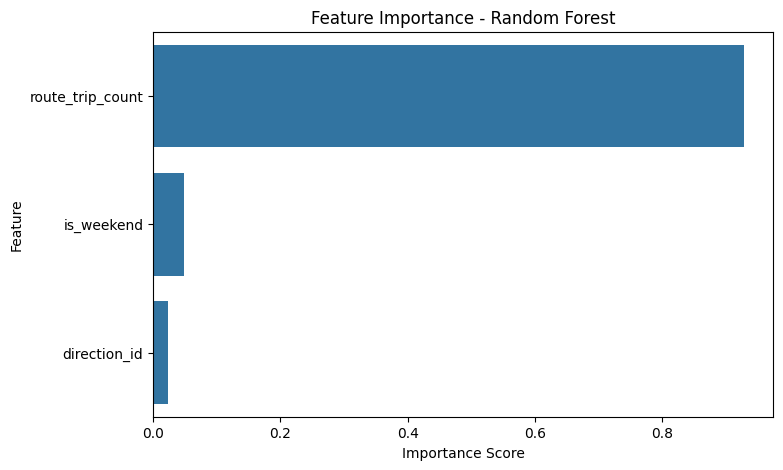

In [121]:
plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


In [122]:
improvement = (rmse_lr - rmse_rf) / rmse_lr * 100
print(f"Random Forest RMSE improvement over Linear Regression: {improvement:.2f}%")


Random Forest RMSE improvement over Linear Regression: 15.88%


In [123]:
residuals = y_test - y_pred_rf


The Random Forest model explains approximately 30.8% of the variance in trip duration (R² = 0.308).

While structural GTFS-derived features contribute meaningfully to prediction performance, a significant portion of variability remains unexplained. This suggests that dynamic operational variables — such as congestion levels, peak-hour effects, and segment-level travel time variability — are necessary to further improve ETA prediction accuracy.

These findings establish a strong structural baseline for future model iterations.


These findings confirm that structural schedule-based features alone are insufficient for high-precision ETA modeling, reinforcing the need for real-time operational data in future iterations.


# Model Evaluation

The Random Forest model outperformed Linear Regression, reducing RMSE by approximately 16%.

This demonstrates that nonlinear models better capture structural variability in trip duration.


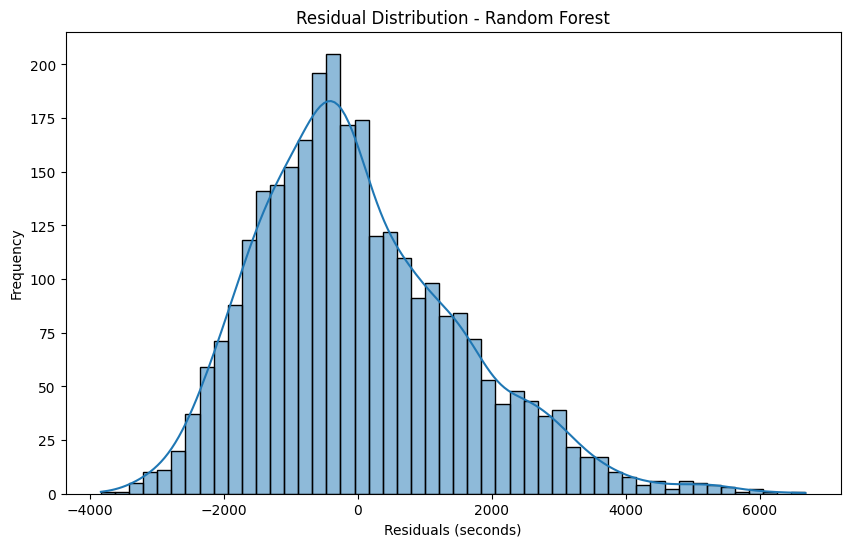

In [124]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(10,6))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Residual Distribution - Random Forest")
plt.xlabel("Residuals (seconds)")
plt.ylabel("Frequency")
plt.show()


##Residual Analysis
The residual distribution of the Random Forest model is approximately centered around zero, indicating limited systematic bias. However, the distribution shows a noticeable positive skew, suggesting that in certain cases the model underestimates trip duration.

Large residuals (above 4000 seconds) indicate high-variability trips that likely depend on operational factors not yet incorporated in the feature set, such as real-time congestion, peak-hour effects, or segment-level travel variability.

This highlights the structural limitation of schedule-based modeling and motivates the integration of dynamic operational features in future iterations.

# Discussion and Technical Findings

The baseline Random Forest model demonstrates that structural GTFS-derived features can partially explain trip duration variability.

However, the residual distribution reveals that large errors remain, particularly for high-variability routes. This suggests that real-time operational features such as congestion levels, peak-hour indicators, and segment-level travel variability are necessary to significantly improve ETA accuracy.


# Future Improvements

Future iterations of this model will incorporate:

- Real-time GPS data
- Peak-hour traffic indicators
- Segment-level modeling
- Cross-validation and hyperparameter tuning
- Model monitoring and drift detection

These improvements will enable a scalable production-grade ETA prediction system suitable for deployment in intelligent transportation platforms.
